In [ ]:
#Importing Libraries
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


#Loading data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

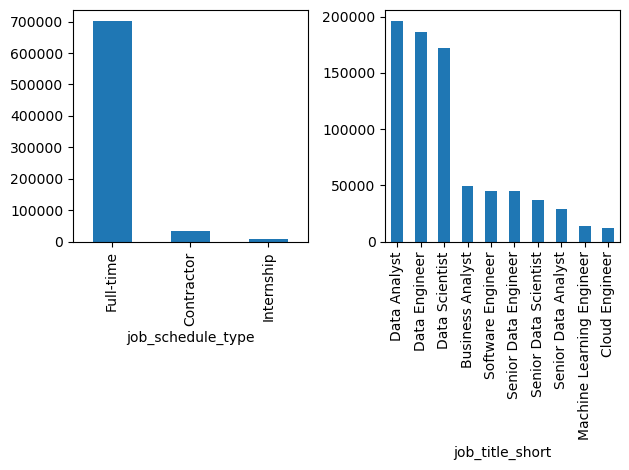

In [20]:
fig, ax = plt.subplots(1,2)
df['job_title_short'].value_counts().plot(kind='bar',ax=ax[1])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar',ax=ax[0])
fig.tight_layout()

In [25]:
import ast
df_skills = df.copy()
df_skills['job_skills'] = df_skills['job_skills'].apply(lambda clean: ast.literal_eval(clean)
                                                 if pd.notna(clean) else clean)
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


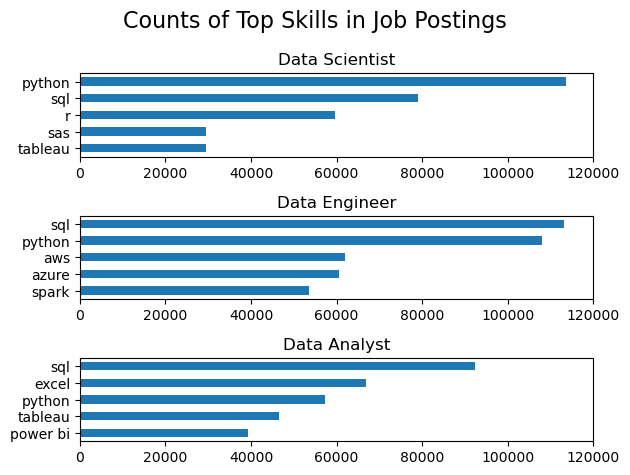

In [39]:
#Create a list
job_titles = ['Data Scientist','Data Engineer','Data Analyst']
fig, ax = plt.subplots(3,1)
for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills',y='skill_count',ax=ax[i],title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0,120000)

fig.suptitle('Counts of Top Skills in Job Postings',fontsize=16)  
fig.tight_layout()  